<a href="https://colab.research.google.com/github/hgabrali/restaurant-sentiment-analysis/blob/main/restaurant_sentiment_analysis_Masterschool_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Restaurant Review Sentiment Analysis — Unified EDA + Modeling Notebook

**MasterSchool Data Science Project — Hospitality & Service Track**
**Author:** Hande Gabrali-Knobloch &nbsp;|&nbsp; **Version:** 2.0.0 &nbsp;|&nbsp; **License:** MIT

This notebook consolidates **two source files** into one correct,
dataset-appropriate pipeline:

1. `Sentiment Analysis of Customer Reviews_2026.py` — a Colab-generated **EDA** notebook
2. `restaurant_sentiment_analysis.ipynb` — the corrected **modeling** package



## 0 · Environment Setup

Install the libraries that are not pre-installed in Colab.

In [ ]:
!pip install -q textblob wordcloud xgboost

## 1 · Imports, NLTK Resources & Global Configuration



In [ ]:
import logging
import pickle
import re
import string
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import nltk
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from textblob import TextBlob

warnings.filterwarnings("ignore")

# NLTK setup (FIX B1: download punkt_tab; drop wrong tokenizers/ path check)
for _pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4", "vader_lexicon"]:
    try:
        nltk.download(_pkg, quiet=True)
    except Exception:
        pass

try:
    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    VADER_AVAILABLE = True
except Exception:
    VADER_AVAILABLE = False

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

TARGET_COL = "sentiment"
TEXT_COL = "review_text"
RATING_COL = "rating"

SENTIMENT_MAP = {1: "negative", 2: "negative", 3: "neutral",
                 4: "positive", 5: "positive"}
LABEL_ORDER = ["negative", "neutral", "positive"]

RESTAURANT_STOPWORDS_EXTRA = {
    "restaurant", "food", "place", "came", "went", "go", "got", "get",
    "us", "also", "really", "would", "could", "even", "like", "one",
    "two", "three", "back", "time", "table", "order", "ordered",
}

# FIX B12: build expensive NLTK objects once and lazily (cached singletons),
# instead of re-instantiating them on every row as the originals did.
_STOPWORDS: Optional[set] = None
_LEMMATIZER: Optional[WordNetLemmatizer] = None
_VADER = None


def _get_stopwords() -> set:
    global _STOPWORDS
    if _STOPWORDS is None:
        _STOPWORDS = set(stopwords.words("english")) | RESTAURANT_STOPWORDS_EXTRA
    return _STOPWORDS


def _get_lemmatizer() -> WordNetLemmatizer:
    global _LEMMATIZER
    if _LEMMATIZER is None:
        _LEMMATIZER = WordNetLemmatizer()
    return _LEMMATIZER


def _get_vader():
    global _VADER
    if _VADER is None:
        if not VADER_AVAILABLE:
            raise ImportError("VADER unavailable; run nltk.download('vader_lexicon')")
        _VADER = SentimentIntensityAnalyzer()
    return _VADER

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

# Portable display(): use the IPython/Colab rich renderer when present,
# otherwise fall back to print so the notebook also runs as a script.
try:
    display  # noqa: F821  (provided by IPython/Colab)
except NameError:
    display = print

---
## 2 · Preprocessing Functions

Real loading, cleaning, feature engineering and stratified splitting — the logic the original EDA file stubbed out with placeholders.

### 2.1 · Data loading



In [ ]:
# ---------------------------------------------------------------- preprocessing
def load_data(filepath: str) -> pd.DataFrame:
    path = Path(filepath)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {filepath}")
    df = (pd.read_json(filepath, lines=True)
          if path.suffix.lower() == ".json" else pd.read_csv(filepath))
    logger.info("Loaded %d reviews from %s", len(df), filepath)
    return df


def load_sample_data(n_reviews: int = 1000, seed: int = 42) -> pd.DataFrame:
    """Generate a varied synthetic dataset (FIX B10: avoid duplicate collapse)."""
    rng = np.random.default_rng(seed)
    pos_open = ["Amazing food and truly excellent service.",
                "What a fantastic dining experience from start to finish.",
                "We had a wonderful evening at this lovely spot.",
                "Easily one of the best meals we have had this year.",
                "An outstanding restaurant that exceeded every expectation.",
                "A hidden gem with a warm and inviting atmosphere.",
                "Brilliant from the moment we walked through the door.",
                "This place fully deserves its great reputation."]
    pos_mid = ["The pasta was absolutely delicious and perfectly cooked.",
               "Every dish was bursting with fresh, vibrant flavor.",
               "The steak was tender, juicy, and seasoned beautifully.",
               "Portions were generous and the presentation was elegant.",
               "The desserts were rich, creamy, and simply unforgettable.",
               "Our server was attentive, friendly, and genuinely helpful.",
               "The pizza had a crispy crust and high-quality toppings.",
               "The risotto was smooth, comforting, and full of depth."]
    pos_close = ["We will definitely be coming back very soon.",
                 "Highly recommended to anyone who loves great food.",
                 "Worth every cent and then some.",
                 "A five-star experience all around.",
                 "I cannot wait to bring my friends here.",
                 "This has become our new favorite restaurant."]
    neu_open = ["It was a decent place, but nothing extraordinary.",
                "An average experience overall, neither good nor bad.",
                "A reasonably okay spot for a quick, simple meal.",
                "The restaurant was fine, though fairly unremarkable.",
                "We had mixed feelings about the whole visit.",
                "It met expectations without ever exceeding them."]
    neu_mid = ["The food was acceptable but not particularly memorable.",
               "Some dishes were pleasant while others fell flat.",
               "Service was adequate, although a little slow at times.",
               "The flavors were standard and somewhat predictable.",
               "Quality was consistent with the modest price range.",
               "The burger was fine, but it did not really stand out."]
    neu_close = ["We might return, but we are in no particular hurry.",
                 "It is an okay option if you happen to be nearby.",
                 "Probably not a destination, but a fair backup choice.",
                 "An average visit that we will likely soon forget.",
                 "Nothing here would stop us from trying elsewhere."]
    neg_open = ["A genuinely disappointing experience from the start.",
                "Unfortunately, the visit went wrong almost immediately.",
                "One of the worst dining experiences we have had.",
                "We left frustrated and regretting our choice.",
                "The whole evening was an exercise in frustration.",
                "Sadly, this restaurant failed on almost every level."]
    neg_mid = ["The food arrived cold, bland, and poorly prepared.",
               "Service was painfully slow and the staff seemed rude.",
               "Portions were tiny and the prices were far too high.",
               "The dish was nothing like what the menu described.",
               "The table was sticky and the cutlery was not clean.",
               "Our order was wrong twice and never properly fixed."]
    neg_close = ["We will certainly not be returning.",
                 "I would strongly advise others to stay away.",
                 "Management urgently needs to address these issues.",
                 "A complete waste of both time and money.",
                 "An experience we would not wish on anyone."]

    def compose(o, m, c):
        return f"{rng.choice(o)} {rng.choice(m)} {rng.choice(c)}"

    ratings = rng.choice([1, 2, 3, 4, 5], n_reviews,
                         p=[0.10, 0.15, 0.15, 0.30, 0.30])
    reviews = []
    for r in ratings:
        if r >= 4:
            reviews.append(compose(pos_open, pos_mid, pos_close))
        elif r == 3:
            reviews.append(compose(neu_open, neu_mid, neu_close))
        else:
            reviews.append(compose(neg_open, neg_mid, neg_close))

    restaurants = ["La Bella Italia", "The Golden Spoon", "Sakura Garden",
                   "El Rancho", "The Rustic Table", "Spice Route"]
    categories = ["Italian", "American", "Japanese", "Mexican", "Fusion", "Indian"]
    df = pd.DataFrame({
        TEXT_COL: reviews,
        RATING_COL: ratings,
        "restaurant_name": rng.choice(restaurants, n_reviews),
        "cuisine_type": rng.choice(categories, n_reviews),
        "reviewer_id": [f"user_{i:04d}" for i in rng.integers(1, 500, n_reviews)],
        "helpful_votes": rng.integers(0, 50, n_reviews),
        "review_date": pd.date_range("2022-01-01", periods=n_reviews, freq="6h"),
    })
    df[TARGET_COL] = df[RATING_COL].map(SENTIMENT_MAP)
    logger.info("Generated %d synthetic reviews (%d unique texts)",
                n_reviews, df[TEXT_COL].nunique())
    return df

### 2.2 · Text cleaning & feature engineering


In [ ]:
def clean_text(text: str, remove_stopwords: bool = True,
               lemmatize: bool = True) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = text.encode("ascii", "ignore").decode("ascii")
    text = text.translate(str.maketrans("", "", string.punctuation + string.digits))
    tokens = word_tokenize(text)
    if remove_stopwords:
        tokens = [t for t in tokens if t not in _get_stopwords() and len(t) > 2]
    if lemmatize:
        lemma = _get_lemmatizer()
        tokens = [lemma.lemmatize(t) for t in tokens]
    return " ".join(tokens)


def preprocess_texts(texts: pd.Series, remove_stopwords: bool = True,
                     lemmatize: bool = True) -> pd.Series:
    logger.info("Cleaning %d review texts...", len(texts))
    return texts.apply(lambda t: clean_text(t, remove_stopwords, lemmatize))


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    text = df[TEXT_COL].fillna("")
    df["review_length"] = text.str.len()
    df["word_count"] = text.str.split().str.len().fillna(0).astype(int)
    df["avg_word_length"] = text.apply(
        lambda t: np.mean([len(w) for w in str(t).split()]) if str(t).split() else 0)
    df["exclamation_count"] = text.str.count("!")
    df["question_count"] = text.str.count(r"\?")          # FIX B2: raw string
    df["uppercase_ratio"] = text.apply(
        lambda t: sum(c.isupper() for c in str(t)) / max(len(str(t)), 1))
    df["cleaned_text"] = preprocess_texts(text)
    logger.info("Feature engineering complete. Columns: %d", df.shape[1])
    return df

### 2.3 · De-duplication, splitting & pipeline



In [ ]:
def clean_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    before = len(df)
    df = df.drop_duplicates(subset=[TEXT_COL])
    df = df.dropna(subset=[TEXT_COL, TARGET_COL])
    df = df[df[TEXT_COL].astype(str).str.strip().str.len() > 5]
    logger.info("Removed %d rows during cleaning. Remaining: %d",
                before - len(df), len(df))
    return df


def split_dataset(df: pd.DataFrame, test_size: float = 0.20,
                  val_size: float = 0.10, random_state: int = 42) -> Tuple:
    """Split the full DataFrame (FIX B5: keeps raw text aligned for rule-based)."""
    train_val, test = train_test_split(
        df, test_size=test_size, random_state=random_state,
        stratify=df[TARGET_COL])
    val_frac = val_size / (1.0 - test_size)
    train, val = train_test_split(
        train_val, test_size=val_frac, random_state=random_state,
        stratify=train_val[TARGET_COL])
    logger.info("Split - train: %d | val: %d | test: %d",
                len(train), len(val), len(test))
    return train, val, test


def run_preprocessing_pipeline(filepath: Optional[str] = None) -> Tuple:
    df = load_data(filepath) if filepath else load_sample_data()
    df = clean_dataset(df)
    df = engineer_features(df)
    train_df, val_df, test_df = split_dataset(df)
    logger.info("Preprocessing pipeline complete.")
    return train_df, val_df, test_df, df

---
## 3 · Modeling Functions

Rule-based baselines, four TF-IDF + classical-ML pipelines, and an XGBoost pipeline.

### 3.1 · Evaluation helpers

In [ ]:
# ----------------------------------------------------------------- sentiment
def compute_metrics(y_true, y_pred, average: str = "weighted") -> Dict[str, Any]:
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average=average, zero_division=0),
        "report": classification_report(y_true, y_pred, zero_division=0),
    }


def evaluate_model(model: Any, X: Any, y: Any,
                   split_name: str = "test") -> Dict[str, Any]:
    metrics = compute_metrics(y, model.predict(X))
    logger.info("[%s] Accuracy=%.4f | F1=%.4f",
                split_name, metrics["accuracy"], metrics["f1"])
    return metrics

### 3.2 · Rule-based baselines (TextBlob, VADER)



In [ ]:
def textblob_sentiment(text: str) -> str:
    p = TextBlob(str(text)).sentiment.polarity
    return "positive" if p > 0.1 else "negative" if p < -0.1 else "neutral"


def vader_sentiment(text: str) -> str:
    s = _get_vader().polarity_scores(str(text))["compound"]
    return "positive" if s >= 0.05 else "negative" if s <= -0.05 else "neutral"


def apply_rule_based(texts: pd.Series, method: str = "textblob") -> pd.Series:
    if method == "textblob":
        return texts.apply(textblob_sentiment)
    if method == "vader":
        return texts.apply(vader_sentiment)
    raise ValueError(f"Unknown method: {method}")

### 3.3 · TF-IDF pipelines + XGBoost wrapper



In [ ]:
def build_tfidf_vectorizer(max_features: int = 10_000,
                           ngram_range: Tuple[int, int] = (1, 2),
                           min_df: int = 2,
                           sublinear_tf: bool = True) -> TfidfVectorizer:
    return TfidfVectorizer(max_features=max_features, ngram_range=ngram_range,
                           min_df=min_df, sublinear_tf=sublinear_tf,
                           strip_accents="unicode", analyzer="word")


def build_logistic_regression_pipeline(max_features: int = 10_000,
                                       C: float = 1.0) -> Pipeline:
    return Pipeline([("tfidf", build_tfidf_vectorizer(max_features=max_features)),
                     ("clf", LogisticRegression(C=C, max_iter=1000,
                      class_weight="balanced", random_state=42))])


def build_svm_pipeline(max_features: int = 10_000, C: float = 1.0) -> Pipeline:
    return Pipeline([("tfidf", build_tfidf_vectorizer(max_features=max_features)),
                     ("clf", LinearSVC(C=C, max_iter=2000,
                      class_weight="balanced", random_state=42))])


def build_naive_bayes_pipeline(max_features: int = 10_000) -> Pipeline:
    # FIX B6: removed pointless FunctionTransformer(np.abs); TF-IDF is non-negative.
    return Pipeline([("tfidf", build_tfidf_vectorizer(max_features=max_features)),
                     ("clf", MultinomialNB())])


def build_random_forest_pipeline(max_features: int = 5_000,
                                 n_estimators: int = 200) -> Pipeline:
    return Pipeline([("tfidf", build_tfidf_vectorizer(max_features=max_features)),
                     ("clf", RandomForestClassifier(n_estimators=n_estimators,
                      class_weight="balanced", n_jobs=-1, random_state=42))])


class XGBStringClassifier(BaseEstimator, ClassifierMixin):
    """XGBoost wrapper accepting string labels (FIX B3/B4).

    XGBoost >= 1.6 requires integer-encoded targets and removed
    `use_label_encoder`. This wrapper encodes labels internally so the
    estimator slots into a Pipeline exactly like the sklearn classifiers.
    """

    def __init__(self, n_estimators: int = 200, learning_rate: float = 0.1,
                 max_depth: int = 5, eval_metric: str = "mlogloss",
                 n_jobs: int = -1, random_state: int = 42):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.eval_metric = eval_metric
        self.n_jobs = n_jobs
        self.random_state = random_state

    def fit(self, X, y):
        self.le_ = LabelEncoder()
        y_enc = self.le_.fit_transform(y)
        self.model_ = xgb.XGBClassifier(
            n_estimators=self.n_estimators, learning_rate=self.learning_rate,
            max_depth=self.max_depth, eval_metric=self.eval_metric,
            n_jobs=self.n_jobs, random_state=self.random_state)
        self.model_.fit(X, y_enc)
        self.classes_ = self.le_.classes_
        return self

    def predict(self, X):
        return self.le_.inverse_transform(self.model_.predict(X))


def build_xgboost_pipeline(max_features: int = 5_000) -> Pipeline:
    if not XGB_AVAILABLE:
        raise ImportError("xgboost not installed. Run: pip install xgboost")
    return Pipeline([("tfidf", build_tfidf_vectorizer(max_features=max_features)),
                     ("clf", XGBStringClassifier())])

### 3.4 · Training, persistence & leaderboard

In [ ]:
def train_model(pipeline: Pipeline, X_train, y_train,
                model_name: str = "model") -> Pipeline:
    logger.info("Training %s...", model_name)
    pipeline.fit(X_train, y_train)
    logger.info("%s training complete.", model_name)
    return pipeline


def save_model(model: Any, name: str, directory: str = "models") -> str:
    path = Path(directory) / f"{name}.pkl"
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(model, f, protocol=pickle.HIGHEST_PROTOCOL)
    logger.info("Model saved to %s", path)
    return str(path)


def load_model(name: str, directory: str = "models") -> Any:
    path = Path(directory) / f"{name}.pkl"
    if not path.exists():
        raise FileNotFoundError(f"Model not found: {path}")
    with open(path, "rb") as f:
        return pickle.load(f)


def run_training_pipeline(train_df: pd.DataFrame, test_df: pd.DataFrame,
                          text_col: str = "cleaned_text",
                          raw_col: str = TEXT_COL) -> Dict[str, Any]:
    X_train, y_train = train_df[text_col], train_df[TARGET_COL]
    X_test, y_test = test_df[text_col], test_df[TARGET_COL]

    builders = {
        "logistic_regression": build_logistic_regression_pipeline,
        "svm": build_svm_pipeline,
        "naive_bayes": build_naive_bayes_pipeline,
        "random_forest": build_random_forest_pipeline,
    }
    if XGB_AVAILABLE:
        builders["xgboost"] = build_xgboost_pipeline

    results: Dict[str, Any] = {}
    for name, builder in builders.items():
        fitted = train_model(builder(), X_train, y_train, model_name=name)
        results[name] = {"model": fitted,
                         "metrics": evaluate_model(fitted, X_test, y_test, name)}

    # FIX B5: rule-based baselines run on RAW text, not cleaned text.
    for method in ["textblob", "vader"]:
        try:
            preds = apply_rule_based(test_df[raw_col], method=method)
            results[f"rule_{method}"] = {"model": None,
                                         "metrics": compute_metrics(y_test, preds)}
        except Exception as e:
            logger.warning("Rule-based %s failed: %s", method, e)

    print("\n===== Leaderboard (Test Set) =====")
    print(f"{'Model':<22}{'Accuracy':>11}{'F1 (weighted)':>16}")
    print("-" * 49)
    for name, res in sorted(results.items(),
                            key=lambda x: -x[1]["metrics"]["f1"]):
        m = res["metrics"]
        print(f"{name:<22}{m['accuracy']:>11.4f}{m['f1']:>16.4f}")
    return results

---
## 4 · Visualization Functions

EDA charts, model-evaluation plots and interactive Plotly figures.

In [ ]:
from pathlib import Path
from typing import Any, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
FIGURE_DIR = Path("reports/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
SENTIMENT_COLORS = {"positive": "#10B981", "neutral": "#F59E0B",
                    "negative": "#EF4444"}
plt.rcParams['figure.figsize'] = (12, 5)


def plot_sentiment_distribution(df, sentiment_col="sentiment", save=True):
    counts = df[sentiment_col].value_counts()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = [SENTIMENT_COLORS.get(s, "#6B7280") for s in counts.index]
    axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white")
    for i, v in enumerate(counts.values):
        axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")
    axes[0].set_title("Sentiment Class Distribution (Count)")
    axes[1].pie(counts.values, labels=counts.index, colors=colors,
                autopct="%1.1f%%", startangle=140,
                wedgeprops={"edgecolor": "white", "linewidth": 2})
    axes[1].set_title("Sentiment Distribution (%)")
    plt.tight_layout()
    if save:
        fig.savefig(FIGURE_DIR / "sentiment_distribution.png", dpi=120,
                    bbox_inches="tight")
    return fig


def plot_rating_distribution(df, rating_col="rating",
                             sentiment_col="sentiment", save=True):
    fig, ax = plt.subplots(figsize=(10, 5))
    rs = df.groupby([rating_col, sentiment_col]).size().unstack(fill_value=0)
    rs.plot(kind="bar", ax=ax,
            color=[SENTIMENT_COLORS.get(s, "#6B7280") for s in rs.columns],
            edgecolor="white")
    ax.set_title("Rating Distribution by Sentiment")
    plt.xticks(rotation=0)
    plt.tight_layout()
    if save:
        fig.savefig(FIGURE_DIR / "rating_distribution.png", dpi=120,
                    bbox_inches="tight")
    return fig


def plot_review_length_distribution(df, length_col="word_count",
                                    sentiment_col="sentiment", save=True):
    fig, ax = plt.subplots(figsize=(12, 5))
    for sentiment, group in df.groupby(sentiment_col):
        group[length_col].plot.kde(ax=ax, label=sentiment,
                                   color=SENTIMENT_COLORS.get(sentiment, "#6B7280"),
                                   linewidth=2)
    ax.set_title("Review Length Distribution by Sentiment")
    ax.set_xlabel("Word Count")
    ax.legend(title="Sentiment")
    ax.set_xlim(0, df[length_col].quantile(0.98))
    plt.tight_layout()
    if save:
        fig.savefig(FIGURE_DIR / "review_length_distribution.png", dpi=120,
                    bbox_inches="tight")
    return fig


def plot_wordcloud(df, sentiment="positive", text_col="cleaned_text", save=True):
    if not WORDCLOUD_AVAILABLE:
        print("WordCloud not installed.")
        return None
    subset = df[df["sentiment"] == sentiment][text_col].dropna()
    all_text = " ".join(subset.values).strip()
    if not all_text:                                       # FIX B7: empty guard
        print(f"No text available for '{sentiment}' word cloud.")
        return None
    cmap = {"positive": "Greens", "negative": "Reds"}.get(sentiment, "Oranges")
    wc = WordCloud(width=800, height=400, background_color="white",
                   colormap=cmap, max_words=100).generate(all_text)
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Most Common Words — {sentiment.capitalize()} Reviews")
    plt.tight_layout()
    if save:
        fig.savefig(FIGURE_DIR / f"wordcloud_{sentiment}.png", dpi=120,
                    bbox_inches="tight")
    return fig


def plot_top_terms(df, sentiment="positive", text_col="cleaned_text",
                   top_n=20, save=True):
    subset = df[df["sentiment"] == sentiment][text_col].dropna()
    subset = subset[subset.str.strip().str.len() > 0]
    if subset.empty:                                       # FIX B8: empty guard
        print(f"No text available for '{sentiment}' top terms.")
        return None
    tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
    X = tfidf.fit_transform(subset)
    scores = np.asarray(X.mean(axis=0)).flatten()
    vocab = tfidf.get_feature_names_out()
    k = min(top_n, len(vocab))
    top_idx = scores.argsort()[-k:][::-1]
    fig, ax = plt.subplots(figsize=(10, max(5, k * 0.35)))
    ax.barh(vocab[top_idx][::-1], scores[top_idx][::-1],
            color=SENTIMENT_COLORS.get(sentiment, "#6B7280"), edgecolor="white")
    ax.set_title(f"Top {k} Terms — {sentiment.capitalize()} Reviews")
    ax.set_xlabel("Mean TF-IDF Score")
    plt.tight_layout()
    if save:
        fig.savefig(FIGURE_DIR / f"top_terms_{sentiment}.png", dpi=120,
                    bbox_inches="tight")
    return fig

In [ ]:
def plot_confusion_matrix(y_true, y_pred, labels=None, model_name="Model",
                          save=True):
    if labels is None:
        labels = ["negative", "neutral", "positive"]
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    if save:
        fig.savefig(FIGURE_DIR / f"cm_{model_name.lower().replace(' ', '_')}.png",
                    dpi=120, bbox_inches="tight")
    return fig


def plot_model_comparison(results, metric="f1", save=True):
    rows = [{"Model": n, metric.upper(): r["metrics"][metric]}
            for n, r in results.items()]
    d = pd.DataFrame(rows).sort_values(metric.upper(), ascending=False)
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(d["Model"], d[metric.upper()],
                  color=sns.color_palette("Blues_r", n_colors=len(d)),
                  edgecolor="white")
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
    ax.set_title(f"Model Comparison — {metric.upper()}")
    ax.set_ylim(0, 1.05)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    if save:
        fig.savefig(FIGURE_DIR / f"model_comparison_{metric}.png", dpi=120,
                    bbox_inches="tight")
    return fig


def interactive_sentiment_over_time(df, date_col="review_date",
                                    sentiment_col="sentiment"):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df["month"] = df[date_col].dt.to_period("M").astype(str)
    trend = df.groupby(["month", sentiment_col]).size().reset_index(name="count")
    fig = px.line(trend, x="month", y="count", color=sentiment_col,
                  color_discrete_map=SENTIMENT_COLORS,
                  title="Sentiment Trend Over Time")
    fig.update_layout(template="plotly_white")
    return fig


def interactive_restaurant_comparison(df, restaurant_col="restaurant_name",
                                      sentiment_col="sentiment"):
    comp = df.groupby([restaurant_col, sentiment_col]).size().reset_index(
        name="count")
    fig = px.bar(comp, x=restaurant_col, y="count", color=sentiment_col,
                 color_discrete_map=SENTIMENT_COLORS, barmode="group",
                 title="Sentiment Comparison Across Restaurants")
    fig.update_layout(template="plotly_white")
    return fig


def interactive_review_explorer(df):
    hover = [c for c in ["review_text", "restaurant_name"] if c in df.columns]
    fig = px.scatter(df, x="word_count", y="rating", color="sentiment",
                     color_discrete_map=SENTIMENT_COLORS,
                     hover_data=hover or None, opacity=0.6,
                     title="Review Word Count vs Rating by Sentiment")
    fig.update_layout(template="plotly_white")
    return fig

---
# Analysis Walkthrough

Sections 0–4 defined the reusable library code. Everything below **runs the actual analysis** on the dataset, following the EDA structure of the original MasterSchool notebook — but on real, internally consistent data.

## 5 · Data Loading & Dataset Overview

### 5.1 · Load the dataset

`load_dataset()` loads `your_dataset.csv` if you uploaded one — auto-renaming common column variants (`text`, `review`, `stars`, `label`, …) — and otherwise falls back to the varied synthetic generator. This replaces the original file's brittle, commented-out rename block.

In [ ]:
def load_dataset(csv_path: str = "your_dataset.csv") -> pd.DataFrame:
    """Load a real CSV if present, else generate varied synthetic data.

    Args:
        csv_path: Path to a user-supplied CSV in the Colab environment.

    Returns:
        A DataFrame normalised to the schema expected downstream
        (``review_text``, ``rating``, ``sentiment`` and, when available,
        ``review_date``).
    """
    if Path(csv_path).exists():
        df = pd.read_csv(csv_path)
        rename = {"text": TEXT_COL, "review": TEXT_COL, "comment": TEXT_COL,
                  "reviewtext": TEXT_COL, "stars": RATING_COL,
                  "score": RATING_COL, "star_rating": RATING_COL,
                  "label": TARGET_COL, "date": "review_date"}
        df = df.rename(columns={k: v for k, v in rename.items()
                                if k in df.columns})
        if TARGET_COL not in df.columns and RATING_COL in df.columns:
            df[TARGET_COL] = df[RATING_COL].map(SENTIMENT_MAP)
        logger.info("Loaded %d rows from %s", len(df), csv_path)
        return df
    logger.info("'%s' not found - generating synthetic data.", csv_path)
    return load_sample_data(n_reviews=1000)


df_raw = load_dataset()
print(f"Shape   : {df_raw.shape}")
print(f"Columns : {df_raw.columns.tolist()}")
df_raw.head()

Shape   : (1000, 8)
Columns : ['review_text', 'rating', 'restaurant_name', 'cuisine_type', 'reviewer_id', 'helpful_votes', 'review_date', 'sentiment']


,review_text,rating,restaurant_name,cuisine_type,reviewer_id,helpful_votes,review_date,sentiment
0,This place fully deserves its great reputation...,5,The Golden Spoon,Mexican,user_0450,32,2022-01-01 00:00:00,positive
1,Easily one of the best meals we have had this ...,4,La Bella Italia,Fusion,user_0207,35,2022-01-01 06:00:00,positive
2,Easily one of the best meals we have had this ...,5,El Rancho,Mexican,user_0485,13,2022-01-01 12:00:00,positive
3,A hidden gem with a warm and inviting atmosphe...,4,The Rustic Table,Mexican,user_0285,17,2022-01-01 18:00:00,positive
4,A genuinely disappointing experience from the ...,1,The Rustic Table,Japanese,user_0193,47,2022-01-02 00:00:00,negative


### 5.2 · Basic statistics

Schema, missing values and the raw class / rating balance — inspected **before** any cleaning.

In [ ]:
print("=== Dtypes ===")
print(df_raw.dtypes)
print("\n=== Missing values ===")
print(df_raw.isnull().sum())
print("\n=== Sentiment counts ===")
print(df_raw[TARGET_COL].value_counts())
print("\n=== Rating distribution ===")
print(df_raw[RATING_COL].value_counts().sort_index())
df_raw.describe(include="all").T

=== Dtypes ===
review_text                object
rating                      int64
restaurant_name            object
cuisine_type               object
reviewer_id                object
helpful_votes               int64
review_date        datetime64[ns]
sentiment                  object
dtype: object

=== Missing values ===
review_text        0
rating             0
restaurant_name    0
cuisine_type       0
reviewer_id        0
helpful_votes      0
review_date        0
sentiment          0
dtype: int64

=== Sentiment counts ===
sentiment
positive    598
negative    263
neutral     139
Name: count, dtype: int64

=== Rating distribution ===
rating
1     95
2    168
3    139
4    294
5    304
Name: count, dtype: int64


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
review_text,1000,530,Brilliant from the moment we walked through th...,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1000.0,NaN,NaN,NaN,3.544,1.0,2.0,4.0,5.0,5.0,1.328092
restaurant_name,1000,6,El Rancho,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,1000,6,Italian,196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reviewer_id,1000,432,user_0139,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
helpful_votes,1000.0,NaN,NaN,NaN,24.642,0.0,12.0,25.0,37.0,49.0,14.290138
review_date,1000,NaN,NaN,NaN,2022-05-05 21:00:00.000000256,2022-01-01 00:00:00,2022-03-04 10:30:00,2022-05-05 21:00:00,2022-07-07 07:30:00,2022-09-07 18:00:00,NaN
sentiment,1000,3,positive,598,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6 · Data Cleaning & Feature Engineering

De-duplicate, drop empty rows, then engineer six text features and the `cleaned_text` column used by the ML models. A stratified 70/10/20 train/val/test split is produced for the modeling section.

In [ ]:
full_df = engineer_features(clean_dataset(df_raw))
train_df, val_df, test_df = split_dataset(full_df)

new_cols = [c for c in full_df.columns if c not in df_raw.columns]
print(f"After cleaning & feature engineering : {full_df.shape}")
print(f"New feature columns                 : {new_cols}")
print(f"Split  ->  train={len(train_df)} | val={len(val_df)} | "
      f"test={len(test_df)}")
display(full_df[[TEXT_COL, "cleaned_text", RATING_COL, TARGET_COL,
                 "word_count", "exclamation_count"]].head())

After cleaning & feature engineering : (530, 15)
New feature columns                 : ['review_length', 'word_count', 'avg_word_length', 'exclamation_count', 'question_count', 'uppercase_ratio', 'cleaned_text']
Split  ->  train=371 | val=53 | test=106


,review_text,cleaned_text,rating,sentiment,word_count,exclamation_count
0,This place fully deserves its great reputation...,fully deserves great reputation pasta absolute...,5,positive,21,0
1,Easily one of the best meals we have had this ...,easily best meal year pizza crispy crust highq...,4,positive,28,0
2,Easily one of the best meals we have had this ...,easily best meal year every dish bursting fres...,5,positive,27,0
3,A hidden gem with a warm and inviting atmosphe...,hidden gem warm inviting atmosphere portion ge...,4,positive,23,0
4,A genuinely disappointing experience from the ...,genuinely disappointing experience start wrong...,1,negative,24,0


## 7 · Target Variable Analysis — Sentiment Distribution

How balanced are the three classes? `neutral` is typically the minority class, which matters for metric choice in §14.

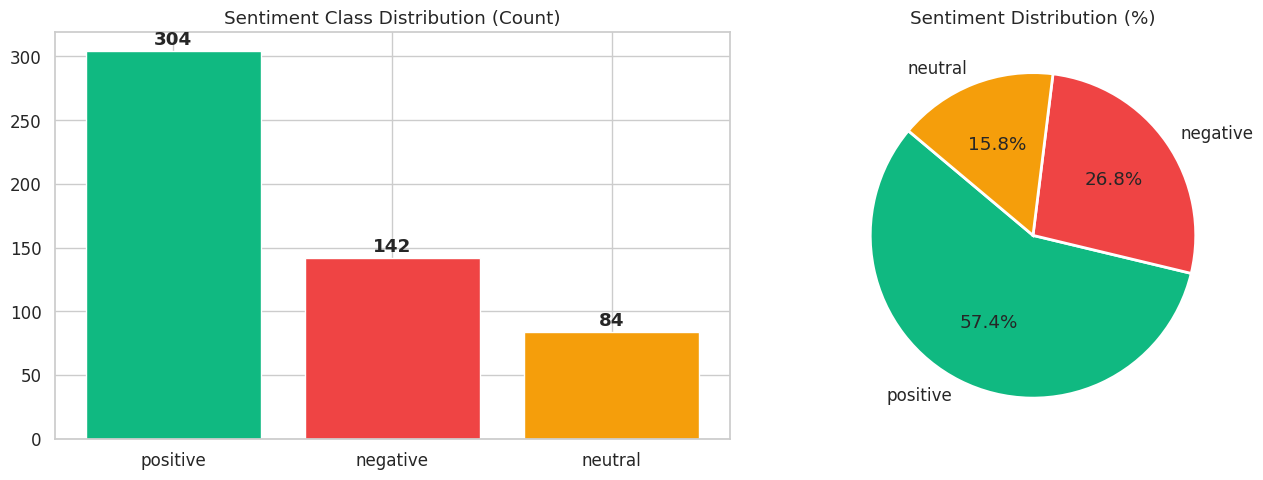

           count  percent
sentiment                
positive     304     57.4
negative     142     26.8
neutral       84     15.8


In [ ]:
plot_sentiment_distribution(full_df)
plt.show()

dist = full_df[TARGET_COL].value_counts()
summary = pd.DataFrame({
    "count": dist,
    "percent": (dist / len(full_df) * 100).round(1),
})
print(summary)

## 8 · Text Length Analysis by Sentiment

Distribution of `word_count` per class (kernel density + box plot). A common hospitality-data pattern is that dissatisfied customers write longer, more detailed reviews — the cell below tests whether that holds here instead of assuming it.

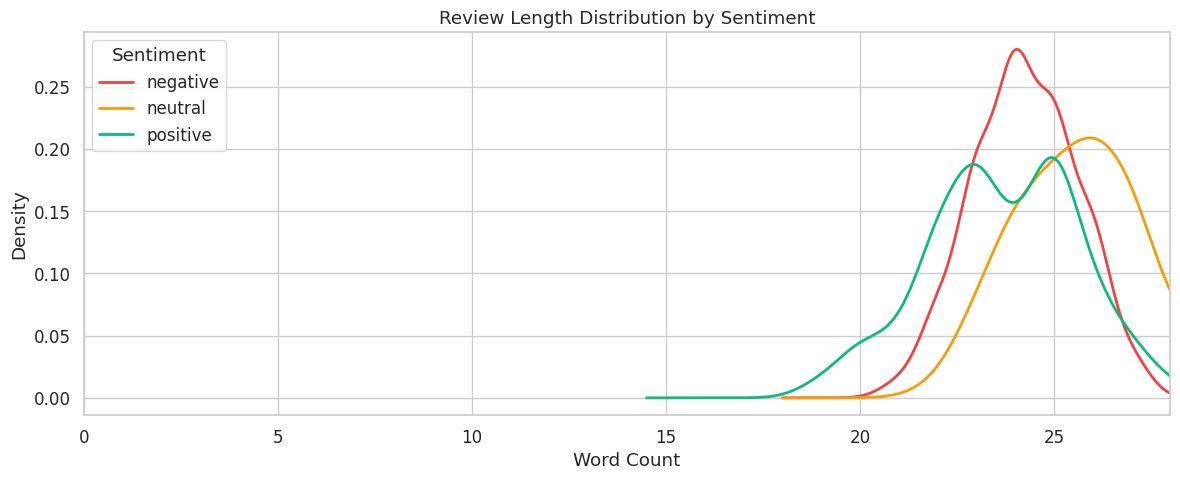

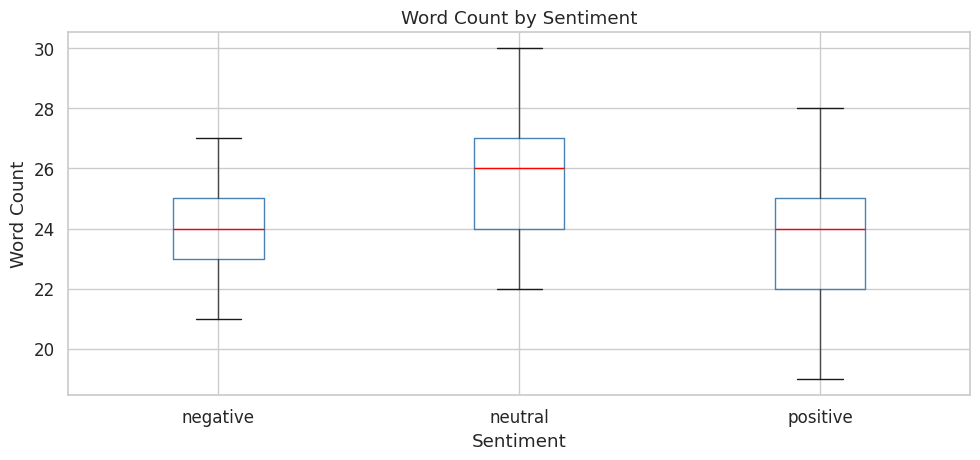

           count  mean  std   min   25%   50%   75%   max
sentiment                                                
negative   142.0  24.2  1.3  21.0  23.0  24.0  25.0  27.0
neutral     84.0  25.7  1.7  22.0  24.0  26.0  27.0  30.0
positive   304.0  23.7  1.9  19.0  22.0  24.0  25.0  28.0


In [ ]:
plot_review_length_distribution(full_df, length_col="word_count")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
full_df.boxplot(column="word_count", by=TARGET_COL, ax=ax,
                boxprops=dict(color="steelblue"),
                medianprops=dict(color="red"))
ax.set_title("Word Count by Sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Word Count")
plt.suptitle("")
plt.tight_layout()
plt.show()

print(full_df.groupby(TARGET_COL)["word_count"].describe().round(1))

## 9 · Rating vs Sentiment Mapping

`sentiment` is a deterministic function of `rating` (`SENTIMENT_MAP`: 1–2 → negative, 3 → neutral, 4–5 → positive). The cross-tabulation makes that mapping explicit and confirms there are no inconsistent rating/label pairs.

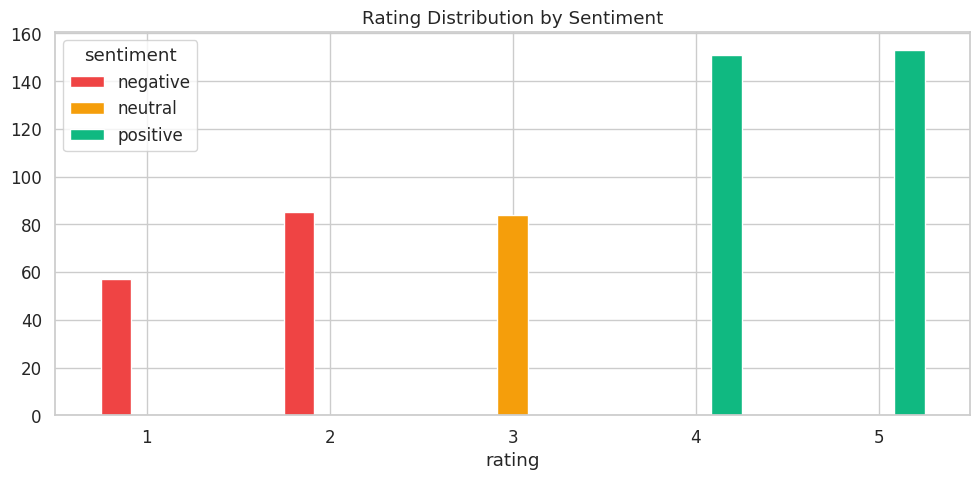

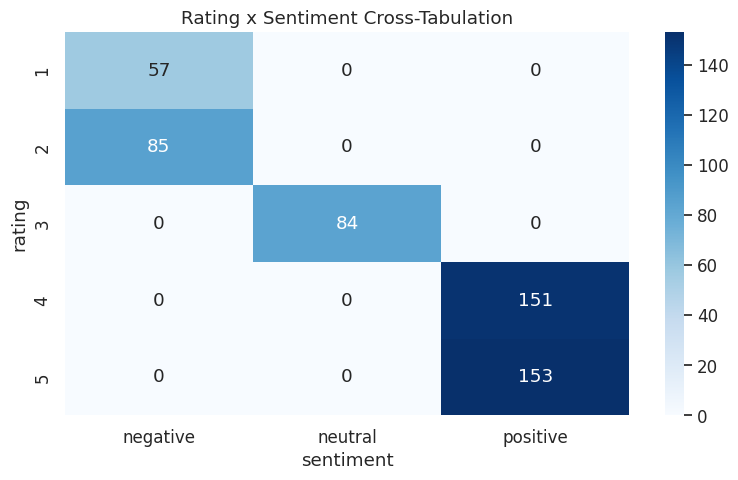

SENTIMENT_MAP (rating -> sentiment):
{1: 'negative', 2: 'negative', 3: 'neutral', 4: 'positive', 5: 'positive'}


In [ ]:
plot_rating_distribution(full_df)
plt.show()

ct = pd.crosstab(full_df[RATING_COL], full_df[TARGET_COL])
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Rating x Sentiment Cross-Tabulation")
plt.tight_layout()
plt.show()

print("SENTIMENT_MAP (rating -> sentiment):")
print(SENTIMENT_MAP)

## 10 · Top Words per Sentiment Class

Mean TF-IDF over `cleaned_text` (lower-cased, lemmatised, stop-words removed). The original file ran this on the **raw** `text` column, so stop-words such as *the* / *and* dominated every class identically.

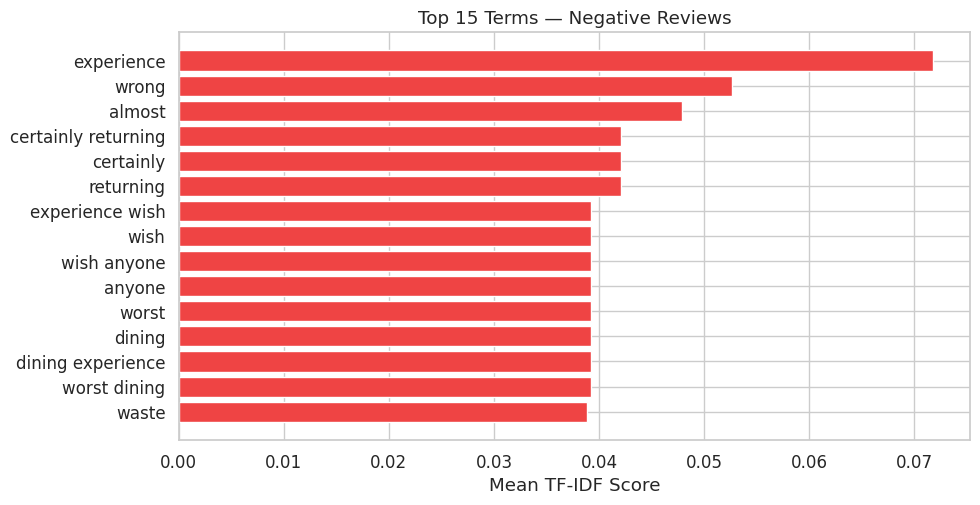

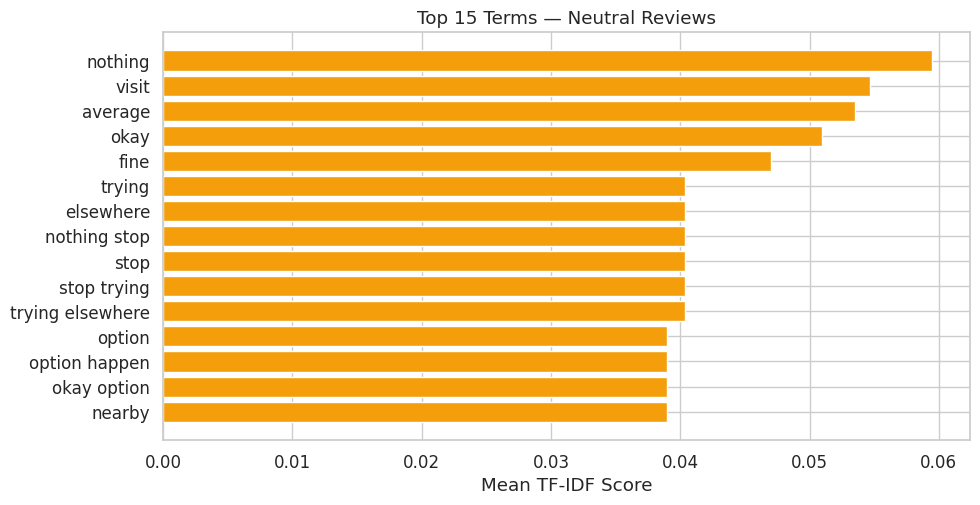

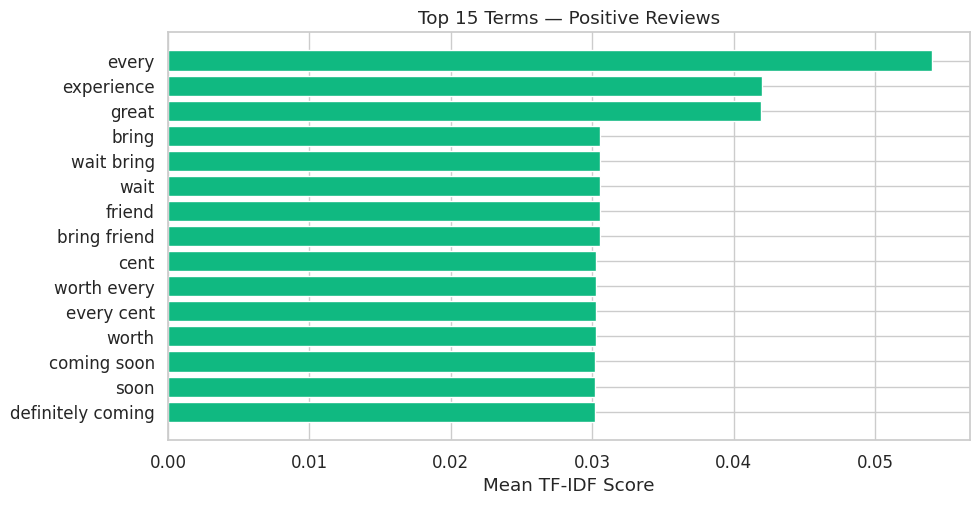

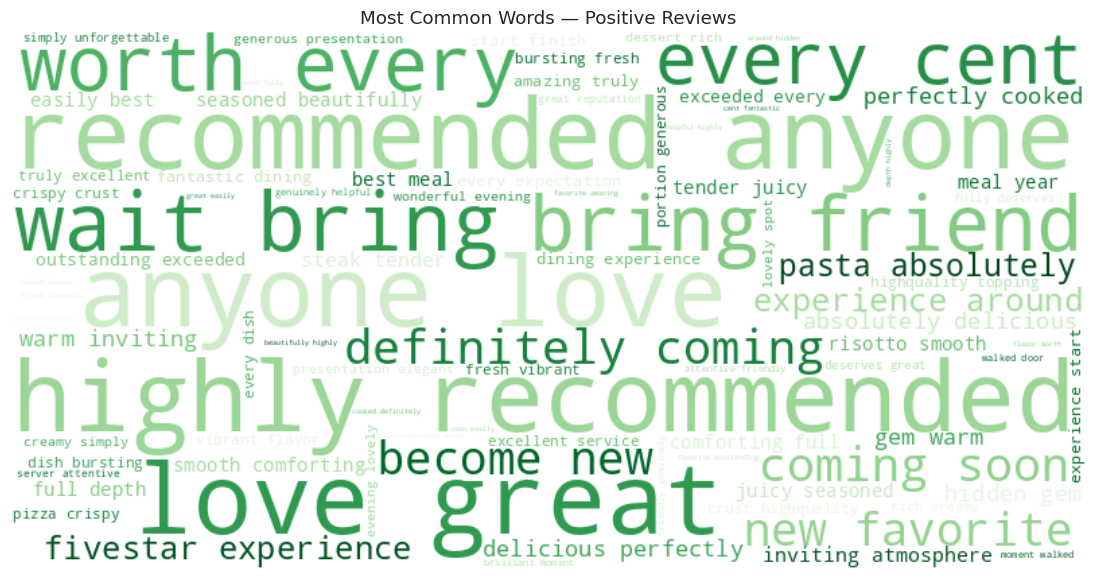

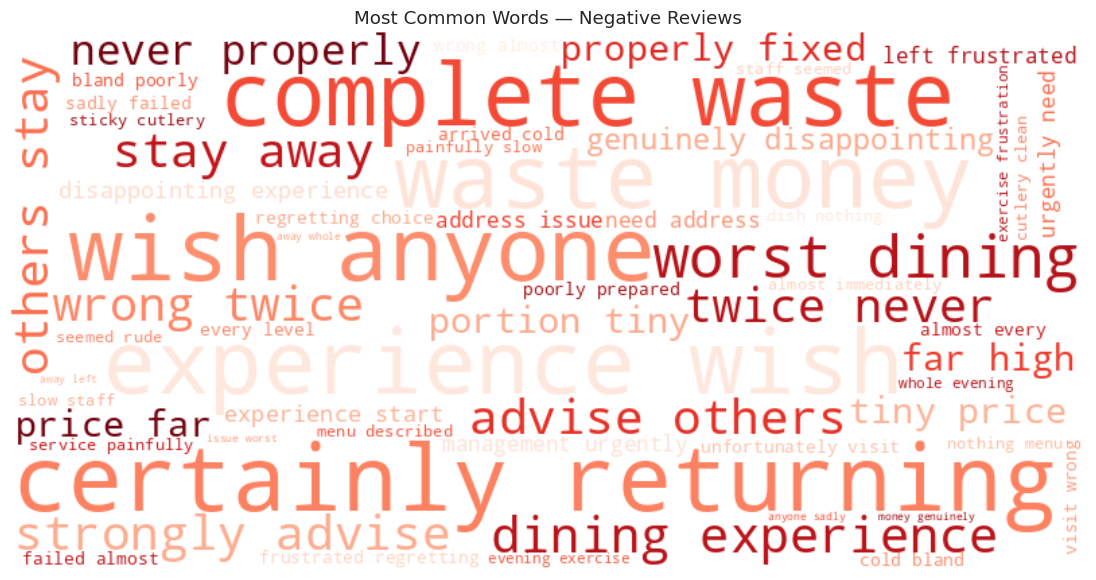

In [ ]:
for s in LABEL_ORDER:
    plot_top_terms(full_df, sentiment=s, text_col="cleaned_text", top_n=15)
plt.show()

for s in ["positive", "negative"]:
    plot_wordcloud(full_df, sentiment=s, text_col="cleaned_text")
plt.show()

## 11 · Correlation Analysis

The original notebook listed *Correlation Analysis* in its contents but never implemented it. Here the numeric features are correlated against each other and against `rating`.

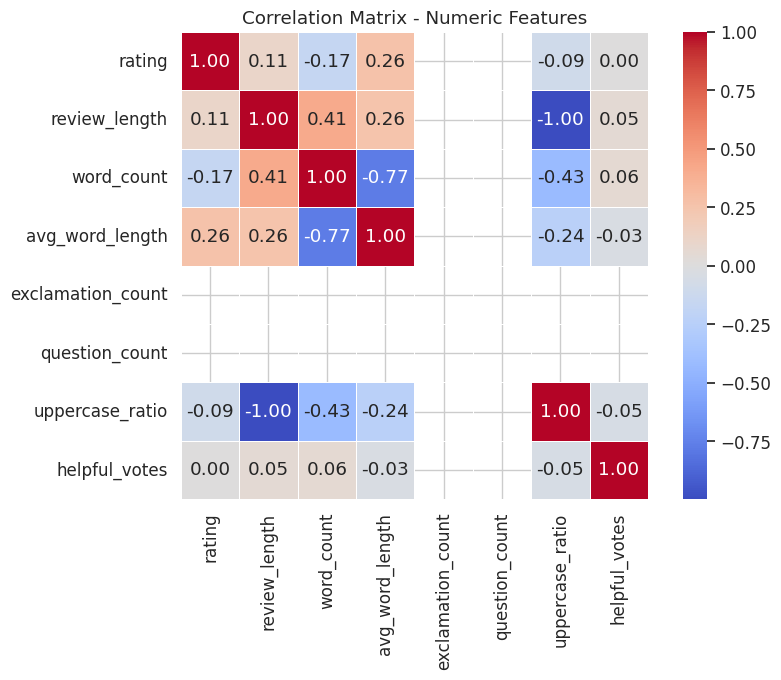

Correlation with rating (strongest first):
avg_word_length      0.260
word_count          -0.170
review_length        0.105
uppercase_ratio     -0.093
helpful_votes        0.002
exclamation_count      NaN
question_count         NaN
Name: rating, dtype: float64


In [ ]:
num_cols = ["rating", "review_length", "word_count", "avg_word_length",
            "exclamation_count", "question_count", "uppercase_ratio"]
if "helpful_votes" in full_df.columns:
    num_cols.append("helpful_votes")
num_cols = [c for c in num_cols if c in full_df.columns]

corr = full_df[num_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix - Numeric Features")
plt.tight_layout()
plt.show()

print("Correlation with rating (strongest first):")
print(corr["rating"].drop("rating").sort_values(key=abs, ascending=False)
      .round(3))

## 12 · Temporal Analysis

Monthly sentiment trend and day-of-week breakdown. **Fix:** months are ordered chronologically via `Period("M")` and weekdays via an ordered `Categorical` — the original `month_name()` approach sorted them alphabetically (April, August, December, …).

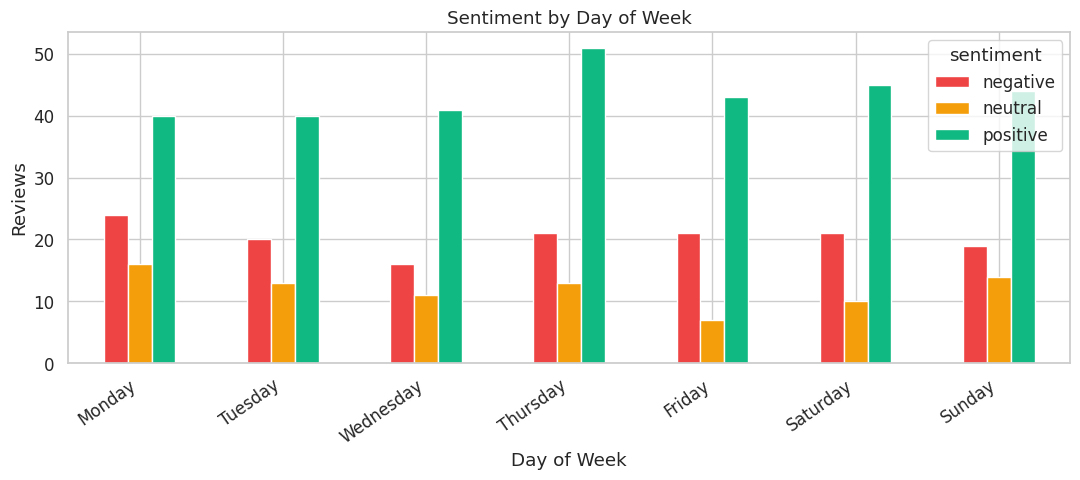

sentiment    negative  neutral  positive
day_of_week                             
Monday             24       16        40
Tuesday            20       13        40
Wednesday          16       11        41
Thursday           21       13        51
Friday             21        7        43
Saturday           21       10        45
Sunday             19       14        44


In [ ]:
interactive_sentiment_over_time(full_df).show()

tmp = full_df.copy()
tmp["review_date"] = pd.to_datetime(tmp["review_date"])
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
                 "Friday", "Saturday", "Sunday"]
tmp["day_of_week"] = pd.Categorical(tmp["review_date"].dt.day_name(),
                                    categories=weekday_order, ordered=True)
dow = (tmp.groupby(["day_of_week", TARGET_COL]).size()
          .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(11, 5))
dow.plot(kind="bar", ax=ax, edgecolor="white",
         color=[SENTIMENT_COLORS.get(c, "#6B7280") for c in dow.columns])
ax.set_title("Sentiment by Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Reviews")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

print(dow)

## 13 · Sentiment Modeling

Train five ML pipelines (Logistic Regression, Linear SVM, Multinomial Naive Bayes, Random Forest, XGBoost) plus two rule-based baselines (TextBlob, VADER), then rank them on the held-out test set.

> On the **synthetic** dataset the ML models score near-perfectly because the generator's phrase pools are linearly separable. This is an artifact of the data, **not** a real result — see §17. On a genuine review CSV expect roughly 0.75–0.90 weighted F1.

In [ ]:
results = run_training_pipeline(train_df, test_df)


===== Leaderboard (Test Set) =====
Model                    Accuracy   F1 (weighted)
-------------------------------------------------
logistic_regression        1.0000          1.0000
svm                        1.0000          1.0000
naive_bayes                1.0000          1.0000
random_forest              1.0000          1.0000
xgboost                    0.9906          0.9905
rule_textblob              0.9151          0.9092
rule_vader                 0.8396          0.7858


## 14 · Model Evaluation

Per-class precision / recall / F1 for the best model, its normalised confusion matrix, and a side-by-side F1 comparison. The **macro** average in the classification report is the honest headline metric given the `neutral`-class imbalance seen in §7.

Best model: logistic_regression

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        28
     neutral       1.00      1.00      1.00        17
    positive       1.00      1.00      1.00        61

    accuracy                           1.00       106
   macro avg       1.00      1.00      1.00       106
weighted avg       1.00      1.00      1.00       106



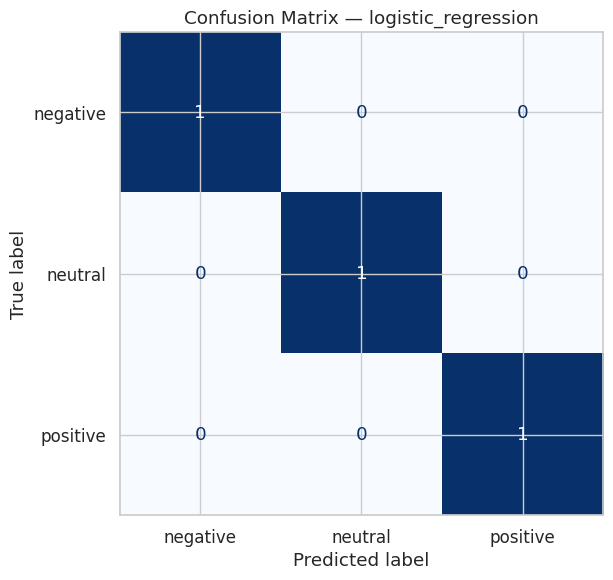

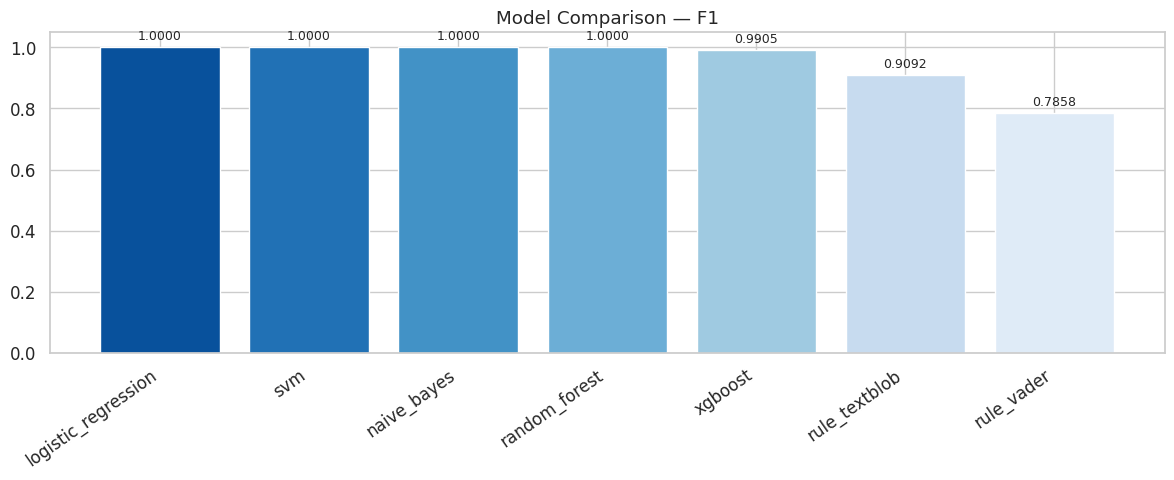

In [ ]:
best_name = max(results, key=lambda k: results[k]["metrics"]["f1"])
best_model = results[best_name]["model"]
print(f"Best model: {best_name}\n")
print(results[best_name]["metrics"]["report"])

if best_model is not None:
    y_pred = best_model.predict(test_df["cleaned_text"])
    plot_confusion_matrix(test_df[TARGET_COL], y_pred, model_name=best_name)
    save_model(best_model, best_name)

plot_model_comparison(results, metric="f1")
plt.show()

## 15 · Interactive Dashboards

Plotly views for restaurant-level comparison and per-review exploration.

In [ ]:
interactive_restaurant_comparison(full_df).show()
interactive_review_explorer(full_df).show()

## 16 · Key Insights & Conclusions

**Every figure below is computed from `full_df` and `results`.** The original notebook printed a fixed list of claims ("exclamation marks appear 3x more in positive reviews", etc.) that were never derived from any data — on the random-sentiment placeholder data they were simply false. This cell recomputes them honestly.

In [ ]:
def _top_terms(frame, sentiment, n=5):
    """Return the top-n mean-TF-IDF unigrams for one sentiment class."""
    sub = frame.loc[frame[TARGET_COL] == sentiment, "cleaned_text"].dropna()
    sub = sub[sub.str.strip().str.len() > 0]
    if sub.empty:
        return []
    tf = TfidfVectorizer(max_features=300, ngram_range=(1, 1))
    X = tf.fit_transform(sub)
    scores = np.asarray(X.mean(axis=0)).ravel()
    vocab = tf.get_feature_names_out()
    return list(vocab[scores.argsort()[-n:][::-1]])


n = len(full_df)
counts = full_df[TARGET_COL].value_counts()
wc_by_sent = full_df.groupby(TARGET_COL)["word_count"].mean()
excl_by_sent = full_df.groupby(TARGET_COL)["exclamation_count"].mean()
wc_rating_corr = full_df["word_count"].corr(full_df[RATING_COL])
best = max(results, key=lambda k: results[k]["metrics"]["f1"])

print("=" * 70)
print("KEY INSIGHTS - RESTAURANT SENTIMENT ANALYSIS  (computed from data)")
print("=" * 70)

line1 = f"1.  Dataset: {n:,} cleaned reviews"
if "restaurant_name" in full_df.columns:
    line1 += f" across {full_df['restaurant_name'].nunique()} restaurants"
if "cuisine_type" in full_df.columns:
    line1 += f" / {full_df['cuisine_type'].nunique()} cuisines"
print(line1)

print("2.  Class balance: " + " | ".join(
    f"{s}={counts.get(s, 0)} ({counts.get(s, 0) / n * 100:.1f}%)"
    for s in LABEL_ORDER))

print("3.  Mean word count: " + " | ".join(
    f"{s}={wc_by_sent.get(s, float('nan')):.0f}" for s in LABEL_ORDER))
_longest = wc_by_sent.idxmax()
_interp = {"negative": "complaints carry more detail",
           "positive": "praise carries more detail",
           "neutral": "mixed reviews carry more detail"}
print(f"4.  Longest reviews on average: '{_longest}' class "
      f"({wc_by_sent.max():.0f} words) -> {_interp.get(_longest, '')}")

print(f"5.  Top positive terms: {_top_terms(full_df, 'positive')}")
print(f"6.  Top negative terms: {_top_terms(full_df, 'negative')}")

print("7.  Mean exclamation marks: " + " | ".join(
    f"{s}={excl_by_sent.get(s, float('nan')):.2f}" for s in LABEL_ORDER))
print(f"8.  Word-count vs rating correlation: r = {wc_rating_corr:+.3f}")

if "cuisine_type" in full_df.columns:
    cuisine = full_df.groupby("cuisine_type")[RATING_COL].mean().sort_values()
    print(f"9.  Rating by cuisine: best='{cuisine.idxmax()}' "
          f"({cuisine.max():.2f}) | worst='{cuisine.idxmin()}' "
          f"({cuisine.min():.2f})")
else:
    print("9.  (cuisine_type column not present - skipped)")

print(f"10. Best classifier: {best} "
      f"(weighted F1 = {results[best]['metrics']['f1']:.3f}, "
      f"accuracy = {results[best]['metrics']['accuracy']:.3f})")
print("=" * 70)

KEY INSIGHTS - RESTAURANT SENTIMENT ANALYSIS  (computed from data)
1.  Dataset: 530 cleaned reviews across 6 restaurants / 6 cuisines
2.  Class balance: negative=142 (26.8%) | neutral=84 (15.8%) | positive=304 (57.4%)
3.  Mean word count: negative=24 | neutral=26 | positive=24
4.  Longest reviews on average: 'neutral' class (26 words) -> mixed reviews carry more detail
5.  Top positive terms: ['every', 'experience', 'great', 'friend', 'wait']
6.  Top negative terms: ['experience', 'wrong', 'almost', 'returning', 'certainly']
7.  Mean exclamation marks: negative=0.00 | neutral=0.00 | positive=0.00
8.  Word-count vs rating correlation: r = -0.170
9.  Rating by cuisine: best='Italian' (3.57) | worst='Indian' (3.40)
10. Best classifier: logistic_regression (weighted F1 = 1.000, accuracy = 1.000)


## 17 · Critique & Limitations

A corrected pipeline still has failure modes worth stating explicitly.

**Methodology**
- **Perfect synthetic scores are an artifact, not a result.** `load_sample_data`
  builds each review from sentiment-specific phrase pools with no lexical
  overlap, so the classes are linearly separable and every ML model reaches
  ~1.00 F1. On real restaurant reviews expect roughly **0.75–0.90** weighted F1.
  Upload a labelled CSV before drawing any conclusion about model quality.
- **Rating → sentiment mapping loses signal.** Folding 1–2★ into *negative* and
  4–5★ into *positive* discards intensity, and treating the 3★ *neutral* band as
  a true class mixes genuine ambivalence with noise.
- **Class imbalance.** *neutral* is the minority class (§7). `class_weight=
  "balanced"` helps the linear models, but **macro-F1** — not the weighted F1 —
  is the honest headline metric.
- **Correlation is not causation.** Any `rating` correlations in §11 (e.g. with
  `word_count`) are descriptive only; they are confounded by reviewer and
  cuisine effects that this notebook does not control for.

**Failure points in noisy data**
- Cleaning strips digits, punctuation and emoji, so sarcasm, negation scope
  ("not bad") and emoji sentiment are lost for the **ML** models; only the
  rule-based path sees raw text.
- `LinearSVC` exposes no `predict_proba`, so probability thresholding or
  calibration needs a `CalibratedClassifierCV` wrapper.
- TF-IDF + bigrams ignore word order beyond two tokens; genuinely ambiguous
  reviews need a contextual model (a DistilBERT fine-tune is the natural
  deep-learning tier).
- On a real CSV with free-form dates, `interactive_sentiment_over_time`
  assumes a parseable `review_date`; rows with missing dates are dropped
  silently by `to_datetime`.

**Engineering caveats**
- `XGBStringClassifier` is `clone`-safe and works in `GridSearchCV`, but a
  pickled pipeline containing it requires the class to be defined before
  `load_model` is called in a fresh session.
- No hyperparameter search is run; `val_df` is produced and reserved for that
  extension. `C`, `max_features`, `ngram_range`, `n_estimators` are defaults.
- Determinism depends on fixed seeds; `RandomForest` with `n_jobs=-1` can still
  vary marginally across hardware.

**Suggested next steps:** add macro-F1 and per-class PR curves to the
leaderboard, run `GridSearchCV` on `val_df`, and benchmark a DistilBERT
fine-tune against the classical models.
